In [1]:
import numpy as np
from numpy.linalg import cholesky, solve
import arviz as az
from scipy.stats import gaussian_kde
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, Hyperparameter
import seaborn as sns
import pytensor
import pytensor.tensor as pt
import pymc as pm
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
from matplotlib.colors import Normalize

set_matplotlib_formats('pdf', 'svg')
sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

# Generate data (at the moment xT3!!)

In [7]:
W_orig = np.load("Dataset/W.npy")  # Our FK-table
xgrid = np.load("Dataset/xgrid.npy")  # Our x-grid
c_yy_orig = np.load("Dataset/c_yy.npy")  # Covariance matrix
y_real = np.load("Dataset/y_real.npy")  # Real data differences
q2_vals = np.load("Dataset/q2_vals.npy")  # Corresponding Q2 values
y_theory = np.load("Dataset/y_theory.npy")  # Corresponding y0 based on W @ (xt3_true) with xt3_true from NNPDF4.0
f0_vals = np.load("Dataset/xt3_true.npy") #Corresponding to the underlying law f0

# test data
f0_test = np.load('Dataset/xt3_test.npy')
xgrid_test = np.load('Dataset/xgrid_test.npy')

print(y_theory)

[0.02494105 0.02509403 0.02552805 0.02561383 0.02921754 0.02929932
 0.02937565 0.02957026 0.0296288  0.02974654 0.02985085 0.02989738
 0.03308076 0.03309478 0.03310411 0.03310003 0.03310284 0.03310032
 0.03321976 0.03320478 0.03318433 0.03316127 0.0331363  0.03310789
 0.03307681 0.03541484 0.03535443 0.03528857 0.0352189  0.03515457
 0.03507973 0.03507973 0.03517758 0.03517758 0.03508489 0.03497988
 0.0348773  0.0348773  0.0347778  0.0347778  0.03467423 0.03456933
 0.03446509 0.03651992 0.03637064 0.03621493 0.03605651 0.03591495
 0.03575696 0.03583775 0.03565679 0.03565679 0.0354455  0.0354455
 0.03525292 0.03525292 0.03507014 0.03507014 0.03488319 0.03488319
 0.03469698 0.03469698 0.03451477 0.03433848 0.03416168 0.03585469
 0.03560803 0.03536028 0.03514136 0.03489968 0.03494111 0.03467515
 0.03467515 0.03438211 0.03438211 0.03408953 0.03408953 0.03408953
 0.03382942 0.03382942 0.03382942 0.03356269 0.03356269 0.0332997
 0.0332997  0.03304438 0.03304438 0.03279921 0.03279921 0.032555

In [3]:
rng = np.random.default_rng(seed=451)  # you can set seed if you want reproducible “data”
noise = rng.multivariate_normal(mean=np.zeros(len(y_theory)), cov=c_yy_orig)

y_pseudo_orig = y_theory + noise

x_star = np.linspace(0, 1, 400) 

In [4]:
# rescale data, centralize it
s = np.std(y_pseudo_orig)  # typical scale of observable

y_pseudo  = y_pseudo_orig / s
c_yy = c_yy_orig / s**2
W  = W_orig / s        # because y = W f

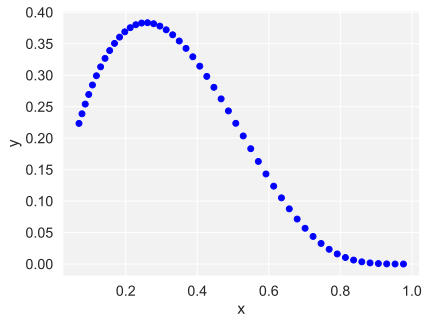

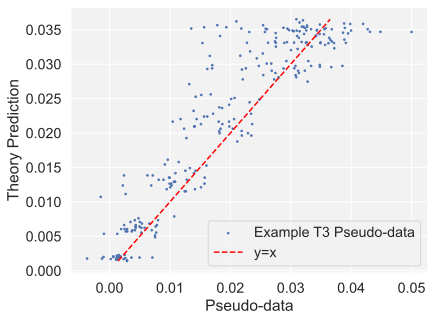

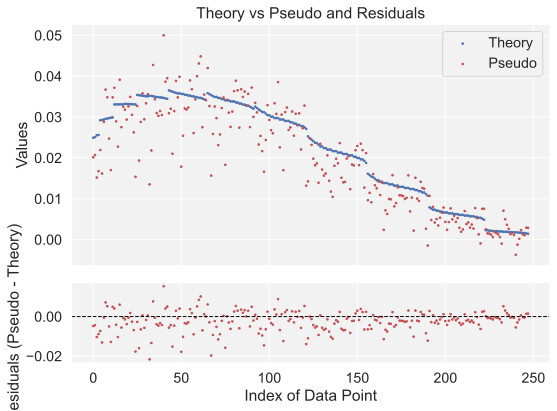

In [6]:
plt.scatter(xgrid, f0_vals, label="Example f0", color="blue")
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

plt.scatter(y_pseudo_orig, y_theory, label="Example T3 Pseudo-data",s=3)
plt.plot([min(y_theory), max(y_theory)],[min(y_theory), max(y_theory)], color="red", linestyle="--", label="y=x")

plt.legend()
plt.xlabel("Pseudo-data")
plt.ylabel("Theory Prediction")
plt.show()
plt.close()

residuals = y_pseudo_orig - y_theory

# Create two vertically stacked subplots (shared x-axis)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 6), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- Top plot: theory vs pseudo
ax1.scatter(np.arange(len(y_theory)), y_theory, s=3, label='Theory')
ax1.scatter(np.arange(len(y_pseudo_orig)), y_pseudo_orig, s=3, label='Pseudo',color='r')
ax1.legend()
ax1.set_ylabel("Values")
ax1.set_title("Theory vs Pseudo and Residuals")

# --- Bottom plot: residuals
ax2.scatter(np.arange(len(residuals)), residuals, s=3, color='r')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("Index of Data Point")
ax2.set_ylabel("Residuals (Pseudo - Theory)")

plt.tight_layout()
plt.show()


look int separate x grid values, what about pseudo data and cov matrix 

In [6]:
print(np.min(xgrid), np.max(xgrid))

0.06925758308452344 0.9764562912534639


## Construct GP using a Gibbs kernel for t3 fitting

## Construct Gibbs kernel

In [7]:
class GibbsKernel1D(Kernel):
    """
    1D Gibbs kernel with linear lengthscale:
        l(x) = l0 * (x + delta)

    delta is FIXED.
    Trainable hyperparameters:
        theta = [log_l0, log_sigma2]
    """

    
    def __init__(
        self,
        alpha=-0.2,
        l0=1.0,
        delta=1e-5,
        sigma2=1.0,
        alpha_bounds=(-1.0, 0.0),
        l0_bounds=(1e-6, 1e6),
        sigma2_bounds=(1e-6, 1e6),
        x_floor=1e-12,   # for logs / powers safety
    ):
        self.alpha = float(alpha)
        self.l0 = float(l0)
        self.delta = float(delta)
        self.sigma2 = float(sigma2)

        self.alpha_bounds = alpha_bounds
        self.l0_bounds = l0_bounds
        self.sigma2_bounds = sigma2_bounds
        self.x_floor = float(x_floor)

    @property
    def hyperparameter_alpha(self):
        return Hyperparameter("alpha", "numeric", self.alpha_bounds)

    @property
    def hyperparameter_l0(self):
        return Hyperparameter("l0", "numeric", self.l0_bounds)

    @property
    def hyperparameter_sigma2(self):
        return Hyperparameter("sigma2", "numeric", self.sigma2_bounds)

    @property
    def theta(self):
        return np.array([self.alpha, np.log(self.l0), np.log(self.sigma2)])

    @theta.setter
    def theta(self, theta):
        self.alpha = float(theta[0])
        self.l0 = float(np.exp(theta[1]))
        self.sigma2 = float(np.exp(theta[2]))

    @property
    def bounds(self):
        return np.array([
            self.alpha_bounds,
            np.log(self.l0_bounds),
            np.log(self.sigma2_bounds),
        ], dtype=float)

    def _ell(self, X):
        x = X[:, 0]
        ell = self.l0 * (x + self.delta)
        return np.maximum(ell, 1e-12)

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        if X.shape[1] != 1:
            raise ValueError("Only 1D inputs (n,1).")
        Y = X if Y is None else np.atleast_2d(Y)
        if Y.shape[1] != 1:
            raise ValueError("Only 1D inputs (m,1).")

        x = X[:, 0][:, None]
        y = Y[:, 0][None, :]

        # base Gibbs part K0
        ell_x = self._ell(X)[:, None]
        ell_y = self._ell(Y)[None, :]

        denom = ell_x**2 + ell_y**2
        diff2 = (x - y) ** 2

        pref0 = np.sqrt(2.0 * ell_x * ell_y / denom)
        expo0 = np.exp(-diff2 / denom)
        K0 = self.sigma2 * pref0 * expo0

        # small-x rescaling
        x_safe = np.maximum(x, self.x_floor)
        y_safe = np.maximum(y, self.x_floor)
        scale = (x_safe ** self.alpha) * (y_safe ** self.alpha)

        K = scale * K0

        if not eval_gradient:
            return K

        # --- gradients

        # dK0/d log l0 (your existing derivation)
        d_ellx_dlogl0 = ell_x
        d_elly_dlogl0 = ell_y

        def dlogK0(d_ellx, d_elly):
            d_denom = 2*ell_x*d_ellx + 2*ell_y*d_elly
            term_pref = 0.5 * (d_ellx/ell_x + d_elly/ell_y - d_denom/denom)
            term_exp  = diff2 * d_denom / (denom**2)
            return term_pref + term_exp

        dlogK0_dlogl0 = dlogK0(d_ellx_dlogl0, d_elly_dlogl0)
        dK0_dlogl0 = K0 * dlogK0_dlogl0

        # chain through scaling
        dK_dlogl0 = scale * dK0_dlogl0
        dK_dlogsigma2 = K  # because K0 linear in sigma2

        # dK/d alpha
        logx = np.log(x_safe)
        logy = np.log(y_safe)
        dK_dalpha = K * (logx + logy)

        grad = np.stack([dK_dalpha, dK_dlogl0, dK_dlogsigma2], axis=2)
        return K, grad

    def diag(self, X):
        X = np.atleast_2d(X)
        x = np.maximum(X[:, 0], self.x_floor)
        return self.sigma2 * (x ** (2*self.alpha))

    def is_stationary(self):
        return False



In [8]:
X_train = xgrid.reshape(-1, 1)   # (N, 1)
X_star  = x_star.reshape(-1, 1)    # (N*,1)

kern = GibbsKernel1D(alpha=-0.2, l0=2, sigma2=0.3, delta=1e-5)

Kxx   = kern(X_train)                 # (N, N)
Ksx   = kern(X_star,  X_train)        # (N*, N)  == K_{x* x}
Kxs   = kern(X_train,  X_star)        # (N, N*)  == K_{x x*}
Kss   = kern(X_star,  X_star)         # (N*, N*) == K_{x* x*}



In [9]:
def log_marginal_likelihood(theta, x_train, FK, CY, y, delta):
    """
    theta = (alpha, l0, sigma2)
    returns log p(y | theta)
    """
    alpha, l0, sigma2 = theta

    # kernel on training grid -> Kxx
    X_train = x_train.reshape(-1, 1)
    kern = GibbsKernel1D(alpha=alpha, l0=l0, sigma2=sigma2, delta=1e-5)
    Kxx = kern(X_train)  # (N, N)

    # data-space covariance CYT
    Cyt = FK @ Kxx @ FK.T + CY
    Cyt = Cyt + 1e-10*np.eye(Cyt.shape[0])  # jitter

    # Cholesky
    # L = cholesky(Cyt)
    try:
        L = np.linalg.cholesky(Cyt)
    except np.linalg.LinAlgError:
        return -np.inf   # invalid θ region

    # quadratic term: y^T CYT^{-1} y
    v = solve(L, y)
    quad = v @ v

    # log determinant
    # logdet = np.sum(np.log(np.diag(Cyt)))
    logdet = 2.0 * np.sum(np.log(np.diag(L)))

    n = y.shape[0]
    logp = -0.5*quad - 0.5*logdet - 0.5*n*np.log(2*np.pi)
    return logp

def log_prior(theta):
    alpha, l0, sigma2 = theta
    if not (-1.0 < alpha < 0.0):
        return -np.inf
    if not (0.0 < l0 < 10.0):
        return -np.inf
    sigma = np.sqrt(sigma2)
    if not (0.0 < sigma < 10.0):
        return -np.inf
    return 0.0

def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_marginal_likelihood(
        theta=theta,
        x_train=xgrid,
        FK=W,
        CY=c_yy,
        y=y_pseudo,
        delta=1e-5
    )

In [10]:
# parameter scan for sampling with NUTS
alphas = np.linspace(-0.999, -0.05, 25)
l0s    = np.logspace(np.log10(0.03), np.log10(5.0), 25)
sig2s  = np.logspace(np.log10(0.05), np.log10(200.0), 25)

best_lp, best_th = -np.inf, None
for a in alphas:
    for l0 in l0s:
        for s2 in sig2s:
            lp = log_posterior((a,l0,s2))
            if lp > best_lp:
                best_lp, best_th = lp, (a,l0,s2)

print(best_th, best_lp)

(np.float64(-0.05), np.float64(2.1313848742262267), np.float64(0.049999999999999996)) -82.0867055994841


## NUTS

In [11]:
delta = 1e-5
x_floor = 1e-12

X_train_t = pt.constant(xgrid.reshape(-1, 1))  # (Ngrid,1)
FK_t      = pt.constant(W)                    # (Ndat, Ngrid)
CY_t      = pt.constant(c_yy)                 # (Ndat, Ndat)
y_t       = pt.constant(y_pseudo)             # (Ndat,)

In [12]:
def Kxx_pt(alpha, l0, sigma2, delta=1e-5):
    """
    Returns Kxx in PyTensor.
    Inputs are PyTensor scalars alpha, l0, sigma2.
    """

    x = X_train_t[:, 0][:, None]   # (N,1)
    y = X_train_t[:, 0][None, :]   # (1,N)

    # lengthscales l(x)=l0*(x+delta)
    ell_x = pt.maximum(l0 * (x + delta), 1e-12)
    ell_y = pt.maximum(l0 * (y + delta), 1e-12)

    denom = ell_x**2 + ell_y**2
    diff2 = (x - y)**2

    pref = pt.sqrt(2.0 * ell_x * ell_y / denom)
    expo = pt.exp(-diff2 / denom)
    K0 = sigma2 * pref * expo

    # small-x rescaling x^alpha y^alpha
    x_safe = pt.maximum(x, x_floor)
    y_safe = pt.maximum(y, x_floor)

    scale = (x_safe**alpha) * (y_safe**alpha)
    return scale * K0

def log_marginal_likelihood_pt(alpha, l0, sigma2, delta=1e-5):
    """
    PyTensor version of log p(y | theta).
    theta = (alpha, l0, sigma2).
    """
    Kxx = Kxx_pt(alpha, l0, sigma2, delta)

    CYT = FK_t @ Kxx @ FK_t.T + CY_t
    CYT = 0.5 * (CYT + CYT.T)

    CYT = CYT + 1e-10*pt.eye(CYT.shape[0])  # jitter

    # Cholesky
    L = pt.linalg.cholesky(CYT)

    # quad term: y^T CYT^{-1} y
    v = pt.linalg.solve_triangular(L, y_t, lower=True)
    quad = pt.dot(v, v)

    # logdet
    logdet = 2.0 * pt.sum(pt.log(pt.diag(L)))

    n = y_t.shape[0]
    logp = -0.5*quad - 0.5*logdet - 0.5*n*pt.log(2*np.pi)
    return logp

def log_prior_pt(alpha, l0, sigma2):
    sigma = pt.sqrt(sigma2)

    in_bounds = (
        (alpha > -1.0) & (alpha < 0.0) &
        (l0 > 0.0) & (l0 < 10.0) &
        (sigma > 0.0) & (sigma < 10.0)
    )
    return pt.switch(in_bounds, 0.0, -np.inf)

def log_posterior_pt(alpha, l0, sigma2):
    return log_prior_pt(alpha, l0, sigma2) + \
           log_marginal_likelihood_pt(alpha, l0, sigma2, delta=1e-5)


In [13]:
th = (-0.3, 5.0, 0.15)
alpha, l0, s2 = th

X_train = xgrid.reshape(-1, 1)

# 1) instantiate kernel with scalars
kern_np = GibbsKernel1D(alpha=alpha, l0=l0, sigma2=s2, delta=delta)

# 2) then call it on arrays to get Kxx
K_np = kern_np(X_train, X_train)

# evaluate PyTensor graph at same theta
alpha_sym = pt.scalar("alpha")
l0_sym    = pt.scalar("l0")
s2_sym    = pt.scalar("s2")

# Build symbolic Kxx
K_pt_expr = Kxx_pt(alpha_sym, l0_sym, s2_sym, delta=delta)

# Compile function that takes (alpha,l0,s2) and returns Kxx
K_pt_fn = pytensor.function([alpha_sym, l0_sym, s2_sym], K_pt_expr)

# Evaluate at the same theta
K_pt = K_pt_fn(alpha, l0, s2)

rel_diff = np.linalg.norm(K_np - K_pt) / np.linalg.norm(K_np)
print("relative diff:", rel_diff)


relative diff: 1.1798508575633394e-16


In [26]:
with pm.Model() as model:
    alpha = pm.Uniform("alpha", -1.0, 0.0)
    l0    = pm.Uniform("l0", 0.0, 10.0)
    sigma = pm.Uniform("sigma", 0.0, 10.0)
    sigma2 = pm.Deterministic("sigma2", sigma**2)

    pm.Potential("posterior_theta", log_posterior_pt(alpha, l0, sigma2))

    trace = pm.sample(
    draws=1000,
    tune=500,
    chains=4,
    cores=1,                
    target_accept=0.99,
    init="jitter+adapt_diag",
    random_seed=123,
)



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [alpha, l0, sigma]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 160 seconds.


In [27]:
#Saving files
az.to_netcdf(trace, "Dataset/posterior_trace_full.nc")

with model:
    trace.extend(pm.sample_posterior_predictive(trace, extend_inferencedata=True))

az.to_netcdf(trace, "Dataset/posterior_plus_ppc_full.nc")

/var/folders/gn/5m9p5_pd4677y7ff0wpgdhyc0000gn/T/ipykernel_97738/2738065411.py:5: UserWarning: The effect of Potentials on other parameters is ignored during posterior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  trace.extend(pm.sample_posterior_predictive(trace, extend_inferencedata=True))


'Dataset/posterior_plus_ppc_full.nc'

## Plotting 

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -0.240  0.198  -0.618   -0.000      0.005    0.004    1758.0    1585.0   
l0     5.602  2.574   1.649    9.973      0.059    0.029    1651.0    1243.0   
sigma  0.273  0.127   0.074    0.490      0.003    0.004    2001.0    1547.0   

       r_hat  
alpha    1.0  
l0       1.0  
sigma    1.0  


array([[<Axes: ylabel='alpha'>, <Axes: >, <Axes: >],
       [<Axes: ylabel='l0'>, <Axes: >, <Axes: >],
       [<Axes: xlabel='alpha', ylabel='sigma'>, <Axes: xlabel='l0'>,
        <Axes: xlabel='sigma'>]], dtype=object)

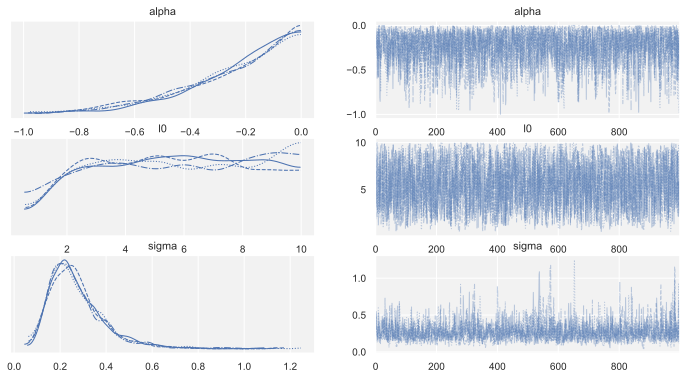

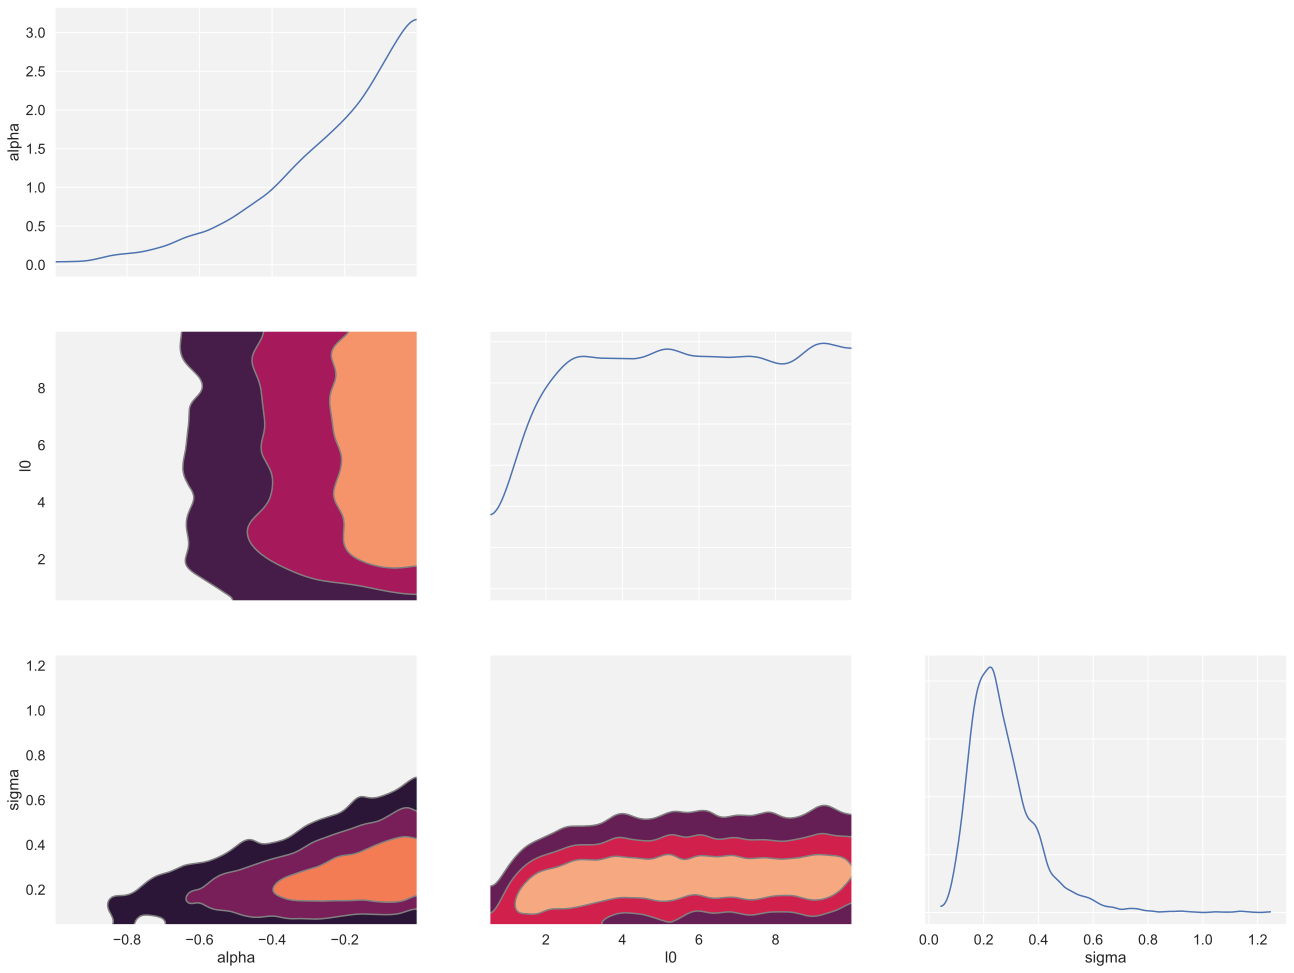

In [28]:
# 1) Text summary
trace = az.from_netcdf("Dataset/posterior_plus_ppc_full.nc")

print(az.summary(trace, var_names=["alpha", "l0", "sigma"]))

# 2) Trace plots (chains + mixing)
az.plot_trace(trace, var_names=["alpha", "l0", "sigma"])

# 3) Pairwise posterior contours
az.plot_pair(
    trace,
    var_names=["alpha", "l0", "sigma"],
    kind="kde",
    marginals=True
)


### Fig 1

In [29]:
def kde_1d(samples, xmin=None, xmax=None, ngrid=400, bw="scott"):
    samples = np.asarray(samples)
    if xmin is None: xmin = samples.min()
    if xmax is None: xmax = samples.max()
    xs = np.linspace(xmin, xmax, ngrid)
    kde = gaussian_kde(samples, bw_method=bw)
    ys = kde(xs)
    return xs, ys

def kde_2d(x, y, xmin=None, xmax=None, ymin=None, ymax=None, ngrid=150, bw="scott"):
    x = np.asarray(x); y = np.asarray(y)
    if xmin is None: xmin = x.min()
    if xmax is None: xmax = x.max()
    if ymin is None: ymin = y.min()
    if ymax is None: ymax = y.max()

    xx, yy = np.meshgrid(
        np.linspace(xmin, xmax, ngrid),
        np.linspace(ymin, ymax, ngrid)
    )
    kde = gaussian_kde(np.vstack([x, y]), bw_method=bw)
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    return xx, yy, zz

def plot_fig1(trace, bw1="scott", bw2="scott", ngrid1=400, ngrid2=150, figsize=(15,12), cb_ranges=None, cmap="viridis", levels=5):
    """
    Rebuild Fig 1:
      left: 1D KDEs for alpha, l0, sigma
      right: 2D KDEs (l0 vs sigma), (l0 vs alpha), (sigma vs alpha)
    """

    # ---- extract samples from trace (works for PyMC InferenceData)
    alpha = trace.posterior["alpha"].values.ravel()
    l0    = trace.posterior["l0"].values.ravel()
    sigma = trace.posterior["sigma"].values.ravel()

    fig, axes = plt.subplots(3, 2, figsize=figsize)

    # ---------------- LEFT COLUMN: 1D KDEs ----------------
    # alpha
    ax = axes[0,0]
    xs, ys = kde_1d(alpha, xmin=-0.9, xmax=0.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$\alpha$ posterior")
    ax.set_xlim(-0.9, 0.0)
    ax.set_ylim(0.0, 4.0)
    ax.set_xlabel(r"$\alpha$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # l0
    ax = axes[1,0]
    xs, ys = kde_1d(l0, xmin=0.0, xmax=10.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$l_0$ posterior")
    ax.set_xlim(0.0, 10.0)
    ax.set_ylim(0.0, 0.16)
    ax.set_xlabel(r"$l_0$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # sigma
    ax = axes[2,0]
    xs, ys = kde_1d(sigma, xmin=0.0, xmax=1.0, ngrid=ngrid1, bw=bw1)
    ax.plot(xs, ys, lw=2, label=r"$\sigma$ posterior")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 4.0)
    ax.set_xlabel(r"$\sigma$")
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.5)

    # ---------------- RIGHT COLUMN: 2D KDEs ----------------
    def contour_panel(ax, x, y, key, xmin, xmax, ymin, ymax, xlabel, ylabel):
        xx, yy, zz = kde_2d(x, y, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
                            ngrid=ngrid2, bw=bw2)

        # pick vmin/vmax from cb_ranges if provided, else use zz min/max
        if cb_ranges and key in cb_ranges:
            vmin, vmax = cb_ranges[key]
        else:
            vmin, vmax = float(zz.min()), float(zz.max())

        # norm = Normalize(vmin=vmin, vmax=vmax)
        cs = ax.contourf(xx, yy, zz, levels=levels, cmap=cmap) #, norm=norm)

        cbar = fig.colorbar(cs, ax=ax)
        cbar.set_ticks(np.linspace(vmin, vmax, levels))  # like your screenshot

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.5)

    # top-right: l0 vs sigma
    contour_panel(
        axes[0,1],
        sigma, l0,
        key="l0_sigma",
        xmin=0.0, xmax=1.0, ymin=0.0, ymax=10.0,
        xlabel=r"$\sigma$", ylabel=r"$l_0$"
    )

    # mid-right: l0 vs alpha
    contour_panel(
        axes[1,1],
        alpha, l0,
        key="l0_alpha",
        xmin=-0.9, xmax=0.0, ymin=0.0, ymax=10.0,
        xlabel=r"$\alpha$", ylabel=r"$l_0$"
    )

    # bottom-right: sigma vs alpha
    contour_panel(
        axes[2,1],
        alpha, sigma,
        key="sigma_alpha",
        xmin=-0.9, xmax=0.0, ymin=0.0, ymax=1.0,
        xlabel=r"$\alpha$", ylabel=r"$\sigma$"
    )

    plt.tight_layout()
    return fig, axes
    


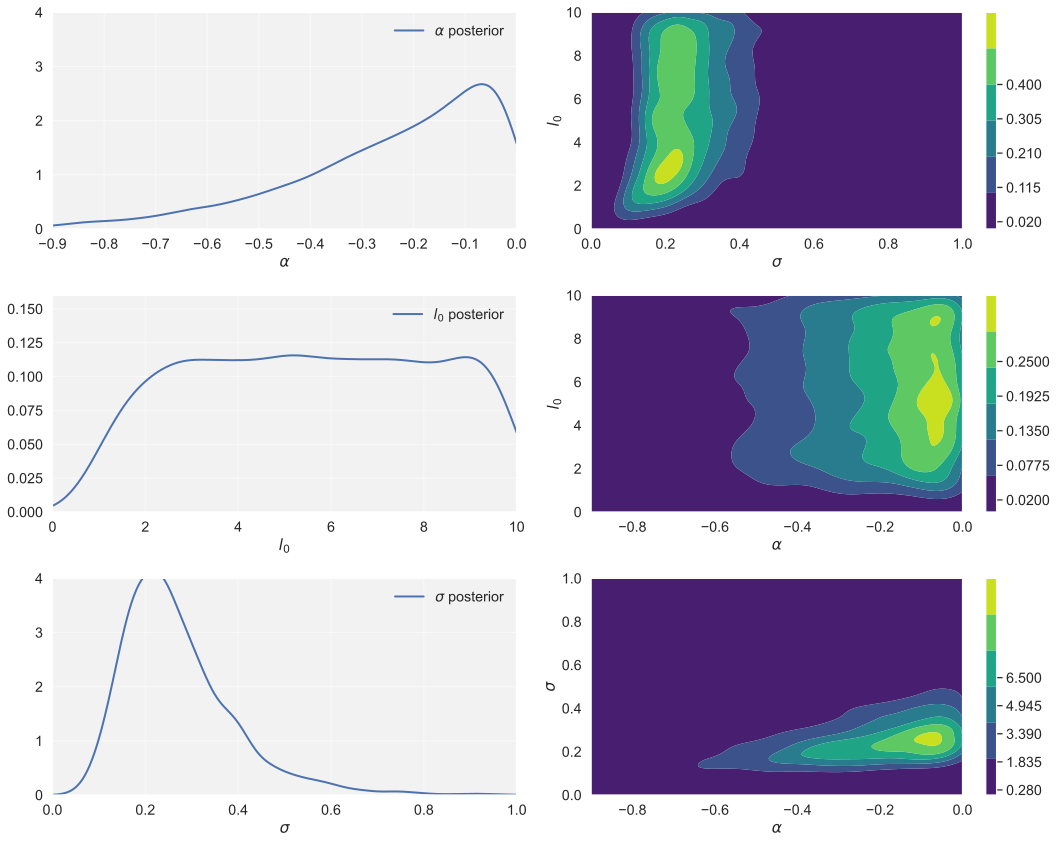

In [30]:
cb_ranges = {
    "l0_sigma":    (0.02, 0.4),
    "l0_alpha":    (0.02, 0.25),
    "sigma_alpha": (0.28,  6.50),
}

fig, axes = plot_fig1(trace,cb_ranges=cb_ranges, bw1=0.2, bw2=0.2)
plt.show()

### Fig 2

- GP posterior on $f^*$ and $x^*$
- get replicas from $x^*$
- Do NUTS again?

In [31]:
def posterior_fstar(theta, FK=W, CY=c_yy, y=y_pseudo):

    alpha, l0, sigma2 = theta
    kern = GibbsKernel1D(alpha=alpha, l0=l0, sigma2=sigma2, delta=1e-5)

    Kxx   = kern(X_train)                 # (N, N)
    Ksx   = kern(X_star,  X_train)        # (N*, N)  == K_{x* x}
    Kxs   = kern(X_train,  X_star)        # (N, N*)  == K_{x x*}
    Kss   = kern(X_star,  X_star)         # (N*, N*)  == K_{x* x*}

    CYT = FK @ Kxx @ FK.T + CY
    CYT = CYT + 1e-10*np.eye(CYT.shape[0])
    L = cholesky(CYT)

    def solve_CYT(b):
        v = solve(L, b)
        return solve(L.T, v)

    # mean
    v = solve_CYT(y)   # CYT^{-1} y
    
    #mstar = mstar_tilde, set mstar = 0                 
    m_star = Ksx @ FK.T @ v            # (N*,)
    m_star = 0.5*(m_star + m_star.T)

    # covariance
    A = solve_CYT(FK @ Ksx.T)          # CYT^{-1}(FK Kxs)  shape (Ndat, N*)
    K_star = Kss - Ksx @ FK.T @ A      # (N*, N*)

    # symmetrize tiny numerical asymmetry
    K_star = 0.5*(K_star + K_star.T)

    return m_star, K_star

In [32]:
replicas = []
means = []

# trace = az.from_netcdf("Dataset/posterior_plus_ppc_full.nc")

alpha_s = trace.posterior["alpha"].values.ravel()
l0_s    = trace.posterior["l0"].values.ravel()
sigma2_s= trace.posterior["sigma2"].values.ravel()

theta_samples = np.stack([alpha_s, l0_s, sigma2_s], axis=1)

print(len(theta_samples))
print(theta_samples)

for theta in theta_samples:
    m_star, K_star = posterior_fstar(theta)
    f_star = np.random.multivariate_normal(m_star, K_star)
    replicas.append(f_star)
    means.append(m_star)

replicas = np.asarray(replicas)   # (S, N*)
means    = np.asarray(means)


4000
[[-0.08464316  4.54665579  0.05731626]
 [-0.25588739  8.29438137  0.06256581]
 [-0.21062064  5.28900419  0.1596876 ]
 ...
 [-0.11451952  3.49840591  0.05443353]
 [-0.09481825  2.51228389  0.06332734]
 [-0.08617782  4.60839524  0.0960411 ]]


/var/folders/gn/5m9p5_pd4677y7ff0wpgdhyc0000gn/T/ipykernel_97738/1354513318.py:17: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  f_star = np.random.multivariate_normal(m_star, K_star)


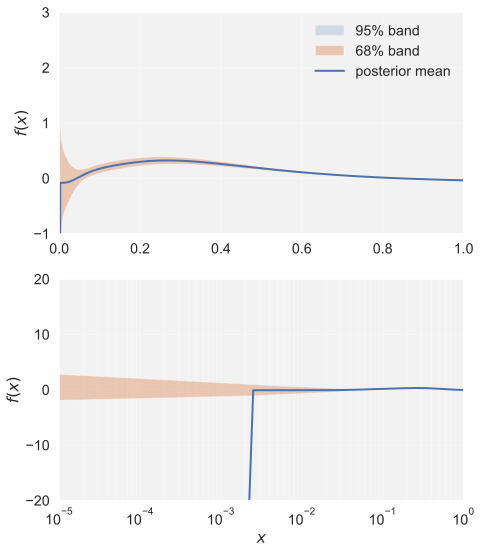

In [43]:
mean_curve = means.mean(axis=0)
lo68, hi68 = np.percentile(replicas, [16, 84], axis=0)
lo95, hi95 = np.percentile(replicas, [2.5, 97.5], axis=0)

# ------------------------------------------
# 6) PLOT FIG 2 (two panels)
# ------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# ---- top: linear x
ax = axes[0]
ax.fill_between(x_star, lo95, hi95, alpha=0.2, label="95% band")
ax.fill_between(x_star, lo68, hi68, alpha=0.4, label="68% band")
ax.plot(x_star, mean_curve, lw=2, label="posterior mean")

# plot a few replicas lightly
# for k in range(min(30, replicas.shape[0])):
#     ax.plot(x_star, replicas[k], alpha=0.1, lw=1)

ax.set_ylabel(r"$f(x)$")
ax.set_xlim([0, 1.0])
ax.set_ylim([-1.0, 3.0])
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# ---- bottom: log-x view (like paper)
ax = axes[1]
ax.fill_between(x_star, lo95, hi95, alpha=0.2)
ax.fill_between(x_star, lo68, hi68, alpha=0.4)
ax.plot(x_star, mean_curve, lw=2)

ax.set_xscale("log")
ax.set_xlim([1e-5, 1.0])
ax.set_ylim([-20.0, 20.0])
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

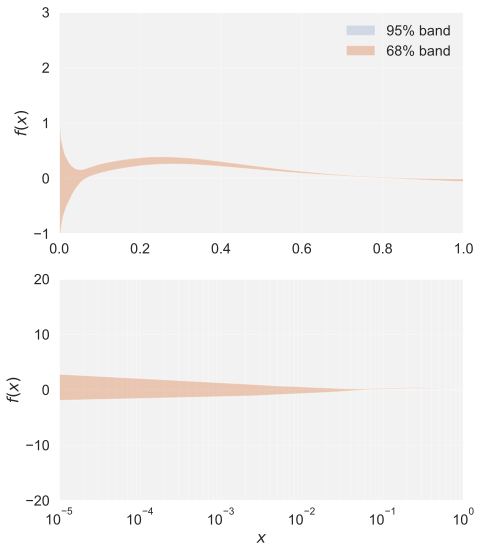

In [ ]:
mean_curve = replicas.mean(axis=0)
lo68, hi68 = np.percentile(replicas, [16, 84], axis=0)
lo95, hi95 = np.percentile(replicas, [2.5, 97.5], axis=0)

# ------------------------------------------
# 6) PLOT FIG 2 (two panels)
# ------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(7, 8))

# ---- top: linear x
ax = axes[0]
ax.fill_between(x_star, lo95, hi95, alpha=0.2, label="95% band")
ax.fill_between(x_star, lo68, hi68, alpha=0.4, label="68% band")
# ax.plot(x_star, mean_curve, lw=2, label="posterior mean")

# plot a few replicas lightly
# for k in range(min(30, replicas.shape[0])):
#     ax.plot(x_star, replicas[k], alpha=0.1, lw=1)

ax.set_ylabel(r"$f(x)$")
ax.set_xlim([0, 1.0])
ax.set_ylim([-1.0, 3.0])
ax.legend(frameon=False)
ax.grid(True, alpha=0.3)

# ---- bottom: log-x view (like paper)
ax = axes[1]
ax.fill_between(x_star, lo95, hi95, alpha=0.2)
ax.fill_between(x_star, lo68, hi68, alpha=0.4)
# ax.plot(x_star, mean_curve, lw=2)

ax.set_xscale("log")
ax.set_xlim([1e-5, 1.0])
ax.set_ylim([-20.0, 20.0])
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$f(x)$")
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()